In [13]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import json

## Load Preprocessed Data

In [14]:
# Load dataset cleaned in 01_data_exploration and 02_data_processing
dt = pd.read_csv('../data/processed/processed.csv')

print(f"Dataset shape: {dt.shape}")
dt.head(3)

Dataset shape: (10234, 12)


,label,subject,speaker,speaker-title,state,party-affiliation,barely-true,false,half-true,mostly-true,pof,article
0,2,2570,2490,866,68,5,0,0,1,1,0,a floor speech. when did the decline of coal s...
1,3,2863,182,641,19,5,70,71,160,163,9,denver hillary clinton agrees with john mccain...
2,1,3075,272,641,61,16,7,19,3,5,44,a news release health care reform legislation ...


## TF-IDF Vectorizer

In [15]:
# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(stop_words='english')

# Fit and transform the text documents
bow_rep_tfidf = tfidf.fit_transform(dt['article'])

print(f"TF-IDF Matrix Shape: {bow_rep_tfidf.shape}")
print(f"Total Unique Vocabulary Size: {len(tfidf.get_feature_names_out())}")

TF-IDF Matrix Shape: (10234, 12583)
Total Unique Vocabulary Size: 12583


## TF-IDF Features for Sample Document

In [16]:
# Inspect top TF-IDF word scores for a sample document
feature_names = tfidf.get_feature_names_out()
sample_vector = bow_rep_tfidf[0]

df_tfidf_sample = pd.DataFrame(
    sample_vector.T.todense(),
    index=feature_names,
    columns=["TF-IDF Score"]
)

df_tfidf_sample = df_tfidf_sample[df_tfidf_sample["TF-IDF Score"] > 0].sort_values(by="TF-IDF Score", ascending=False)

print()
print(f"Top TF-IDF Words for the first sample: \n{dt['article'][0]}")
df_tfidf_sample.head(10)


Top TF-IDF Words for the first sample: 
a floor speech. when did the decline of coal start? it started when natural gas took off that started to begin in (president george w.) bushs administration.


,TF-IDF Score
started,0.493277
decline,0.305127
begin,0.294204
bushs,0.283281
natural,0.272956
coal,0.269502
start,0.262034
gas,0.219428
george,0.209398
took,0.198560


## Train Classification Model

In [17]:
# Categorical column
categorical_cols = ['subject', 'speaker', 'speaker-title', 'state', 'party-affiliation']

# Numerical credit history count columns
numerical_cols = ['barely-true', 'false', 'half-true', 'mostly-true', 'pof']

X = dt[['article'] + categorical_cols + numerical_cols]
y = dt['label']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set shape: {X_train.shape}, Test set shape: {X_test.shape}")

Train set shape: (8187, 11), Test set shape: (2047, 11)


In [18]:
X.head(3)

,article,subject,speaker,speaker-title,state,party-affiliation,barely-true,false,half-true,mostly-true,pof
0,a floor speech. when did the decline of coal s...,2570,2490,866,68,5,0,0,1,1,0
1,denver hillary clinton agrees with john mccain...,2863,182,641,19,5,70,71,160,163,9
2,a news release health care reform legislation ...,3075,272,641,61,16,7,19,3,5,44


In [19]:
categorical_cols = ['subject', 'speaker', 'speaker-title', 'state', 'party-affiliation']
numerical_cols = ['barely-true', 'false', 'half-true', 'mostly-true', 'pof']

preprocessor = ColumnTransformer([
    ('text', TfidfVectorizer(stop_words='english'), 'article'),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numerical_cols)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

# Train the model
model.fit(X_train, y_train)

/Users/rumethsandinu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(stop_words='english'),
                                                  'article'),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['subject', 'speaker',
                                                   'speaker-title', 'state',
                                                   'party-affiliation']),
                                                 ('num', StandardScaler(),
                                                  ['barely-true', 'false',
                                                   'half-true', 'mostly-true',
                                                   'pof'])])),
                ('classifier', LogisticRegression())])

## Evaluate Model Performance

In [20]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")

Train Accuracy: 0.8608
Test Accuracy:  0.2648


In [21]:
print("Test Classification Report:\n", classification_report(y_test, y_test_pred))

Test Classification Report:
               precision    recall  f1-score   support

           0       0.26      0.23      0.24       331
           1       0.27      0.29      0.28       399
           2       0.25      0.27      0.26       422
           3       0.25      0.30      0.27       392
           4       0.40      0.20      0.26       168
           5       0.27      0.26      0.26       335

    accuracy                           0.26      2047
   macro avg       0.28      0.26      0.26      2047
weighted avg       0.27      0.26      0.26      2047



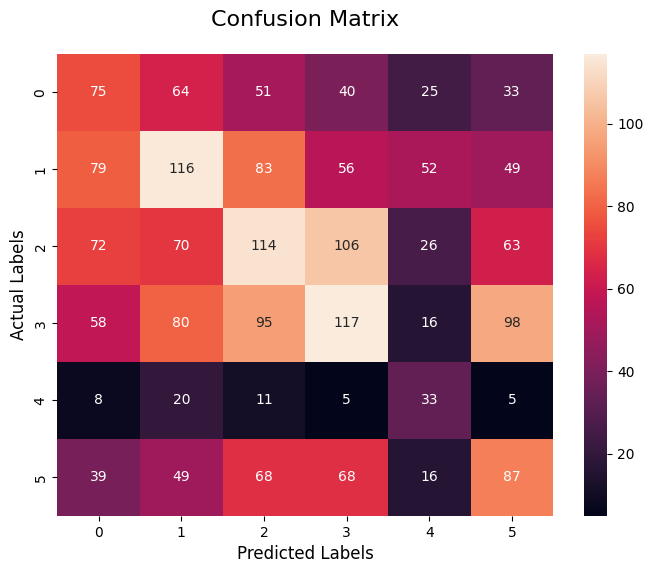

In [22]:
cm = confusion_matrix(y_test_pred, y_test)
plt.figure(figsize=(8, 6))

# 4. Plot the heatmap using Seaborn
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    # xticklabels=class_names,  # Class labels on x-axis
    # yticklabels=class_names,  # Class labels on y-axis
)

plt.title("Confusion Matrix", fontsize=16, pad=20)
plt.xlabel("Predicted Labels", fontsize=12)
plt.ylabel("Actual Labels", fontsize=12)

plt.show()

In [23]:
results = {
    "train_accuracy": accuracy_score(y_train, y_train_pred),
    "test_accuracy": accuracy_score(y_test, y_test_pred),
    "classification_report": classification_report(y_test, y_test_pred, output_dict=True),
    "confusion_matrix": confusion_matrix(y_test, y_test_pred).tolist()
}

with open("../artifacts/results.json", "w") as file:
    json.dump(results, file, indent=4)